
# AOI 3 Bologna HyP3/GAMMA MintPy Stepwise Review

This notebook is tailored to the processed HyP3/GAMMA stack at `/mnt/data/aoi_3_bologna/mintpy_filtered`.

It mirrors the workflow that was actually run:

1. `load_data`
2. `modify_network`
3. `reference_point`
4. `quick_overview`
5. `invert_network`
6. `correct_SET`
7. `correct_troposphere`
8. `deramp`
9. `correct_topography`
10. `residual_RMS`
11. `velocity`
12. export products (`KMZ`, `HDF-EOS5`)

The final section provides a clickable velocity explorer. Click a point on the final corrected velocity map to compare the full LOS time-series chain:

- raw `timeseries.h5`
- `timeseries_SET.h5`
- `timeseries_SET_ERA5.h5`
- `timeseries_SET_ERA5_ramp.h5`
- `timeseries_SET_ERA5_ramp_demErr.h5`

All displacement remains in LOS. This notebook does not convert the stack to vertical motion.


In [9]:

import os
os.environ.setdefault('MPLCONFIGDIR', '/mnt/data/tmp/matplotlib')

from pathlib import Path
from IPython.display import Markdown, display, FileLink, IFrame
from IPython import get_ipython
import warnings

import h5py
import ipywidgets as widgets
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

import matplotlib.pyplot as plt
from scipy import ndimage as ndi

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['image.cmap'] = 'viridis'

WORK_DIR = Path('/mnt/data/aoi_3_bologna/mintpy_filtered')
INPUTS_DIR = WORK_DIR / 'inputs'
CONFIG_FILE = Path('/home/ubuntu/work/mintpy-playbook/configs/aoi_3_bologna_hyp3_filtered.cfg')
GUIDE_FILE = Path('/home/ubuntu/work/mintpy-playbook/docs/AOI3_HYP3_GAMMA_STEPWISE_GUIDE.md')

FILES = {
    'ifgramStack': INPUTS_DIR / 'ifgramStack.h5',
    'geometry': INPUTS_DIR / 'geometryGeo.h5',
    'avgSpatialCoh': WORK_DIR / 'avgSpatialCoh.h5',
    'avgPhaseVelocity': WORK_DIR / 'avgPhaseVelocity.h5',
    'ambiguity': WORK_DIR / 'numTriNonzeroIntAmbiguity.h5',
    'temporalCoherence': WORK_DIR / 'temporalCoherence.h5',
    'numInvIfgram': WORK_DIR / 'numInvIfgram.h5',
    'timeseries_raw': WORK_DIR / 'timeseries.h5',
    'timeseries_set': WORK_DIR / 'timeseries_SET.h5',
    'timeseries_era5': WORK_DIR / 'timeseries_SET_ERA5.h5',
    'timeseries_ramp': WORK_DIR / 'timeseries_SET_ERA5_ramp.h5',
    'timeseries_final': WORK_DIR / 'timeseries_SET_ERA5_ramp_demErr.h5',
    'timeseries_residual': WORK_DIR / 'timeseriesResidual_ramp.h5',
    'velocity': WORK_DIR / 'velocity.h5',
    'velocity_era5': WORK_DIR / 'velocityERA5.h5',
    'demErr': WORK_DIR / 'demErr.h5',
    'maskTempCoh': WORK_DIR / 'maskTempCoh.h5',
    'waterMask': WORK_DIR / 'waterMask.h5',
    'set_model': INPUTS_DIR / 'SET.h5',
    'era5_model': INPUTS_DIR / 'ERA5.h5',
    'network_pdf': WORK_DIR / 'network.pdf',
    'coherence_matrix_pdf': WORK_DIR / 'coherenceMatrix.pdf',
    'coherence_history_pdf': WORK_DIR / 'coherenceHistory.pdf',
    'pbase_history_pdf': WORK_DIR / 'pbaseHistory.pdf',
    'coherence_txt': WORK_DIR / 'coherenceSpatialAvg.txt',
    'rms_txt': WORK_DIR / 'rms_timeseriesResidual_ramp.txt',
    'reference_date': WORK_DIR / 'reference_date.txt',
    'kmz': WORK_DIR / 'velocity.kmz',
    'he5': WORK_DIR / 'S1_IW123_168_0000_20170104_20250627.he5',
}

TS_CHAIN = [
    ('Raw LOS', FILES['timeseries_raw']),
    ('SET corrected', FILES['timeseries_set']),
    ('SET + ERA5', FILES['timeseries_era5']),
    ('SET + ERA5 + deramp', FILES['timeseries_ramp']),
    ('Final corrected', FILES['timeseries_final']),
]

STEP_OUTPUTS = {
    'load_data': [FILES['ifgramStack'], FILES['geometry']],
    'modify_network': [FILES['avgSpatialCoh'], FILES['waterMask'], FILES['network_pdf'], FILES['coherence_txt']],
    'reference_point': [FILES['avgSpatialCoh'], FILES['ifgramStack']],
    'quick_overview': [FILES['avgPhaseVelocity'], FILES['ambiguity']],
    'invert_network': [FILES['timeseries_raw'], FILES['temporalCoherence'], FILES['numInvIfgram'], FILES['maskTempCoh']],
    'correct_SET': [FILES['set_model'], FILES['timeseries_set']],
    'correct_troposphere': [FILES['era5_model'], FILES['timeseries_era5']],
    'deramp': [FILES['timeseries_ramp']],
    'correct_topography': [FILES['timeseries_final'], FILES['demErr']],
    'residual_RMS': [FILES['timeseries_residual'], FILES['rms_txt'], FILES['reference_date']],
    'velocity': [FILES['velocity'], FILES['velocity_era5']],
    'exports': [FILES['kmz'], FILES['he5']],
}


def read_attrs(path):
    with h5py.File(path, 'r') as f:
        return dict(f.attrs)


def default_dataset(path):
    with h5py.File(path, 'r') as f:
        keys = list(f.keys())
    for key in keys:
        if key not in ('date', 'bperp', 'dropIfgram'):
            return key
    return keys[0]


def read_2d(path, key=None, step=1):
    key = key or default_dataset(path)
    with h5py.File(path, 'r') as f:
        arr = f[key][::step, ::step]
    return np.array(arr)


def read_mask(path, step=1):
    with h5py.File(path, 'r') as f:
        key = list(f.keys())[0]
        arr = f[key][::step, ::step]
    return np.array(arr).astype(bool)

def make_display_mask(step=1, dilate_iter=1):
    m = read_mask(FILES['maskTempCoh'], step=step)
    support = ndi.binary_dilation(m, iterations=dilate_iter) if dilate_iter else m
    labels, n = ndi.label(support)
    if n == 0:
        return m
    counts = np.bincount(labels.ravel())
    largest = np.argmax(counts[1:]) + 1
    return m & (labels == largest)


def read_timeseries_slice(path, date_index, step=1):
    with h5py.File(path, 'r') as f:
        arr = f['timeseries'][date_index, ::step, ::step]
    return np.array(arr)


def read_point_timeseries(path, y, x):
    with h5py.File(path, 'r') as f:
        vals = f['timeseries'][:, y, x]
        dates = [d.decode() if isinstance(d, bytes) else str(d) for d in f['date'][:]]
    return np.array(vals), pd.to_datetime(dates, format='%Y%m%d')


def read_dates(path):
    with h5py.File(path, 'r') as f:
        dates = [d.decode() if isinstance(d, bytes) else str(d) for d in f['date'][:]]
    return dates, pd.to_datetime(dates, format='%Y%m%d')


def read_point_value(path, key, y, x):
    with h5py.File(path, 'r') as f:
        return float(f[key][y, x])


def utm_crs_from_attrs(attrs):
    zone = attrs.get('UTM_ZONE')
    if zone is None:
        return None
    if isinstance(zone, bytes):
        zone = zone.decode()
    zone = str(zone).strip().upper()
    if not zone:
        return None
    zone_num = int(''.join(ch for ch in zone if ch.isdigit()))
    hemi = 'south' if zone.endswith('S') else 'north'
    return CRS.from_dict({'proj': 'utm', 'zone': zone_num, 'south': hemi == 'south', 'datum': 'WGS84'})


PROJECT_ATTRS = read_attrs(FILES['velocity'])
PROJECT_CRS = utm_crs_from_attrs(PROJECT_ATTRS)
TO_LONLAT = Transformer.from_crs(PROJECT_CRS, CRS.from_epsg(4326), always_xy=True) if PROJECT_CRS else None


def xy_from_yx(attrs, y, x):
    x_val = float(attrs['X_FIRST']) + x * float(attrs['X_STEP'])
    y_val = float(attrs['Y_FIRST']) + y * float(attrs['Y_STEP'])
    return x_val, y_val


def lonlat_from_yx(attrs, y, x):
    x_val, y_val = xy_from_yx(attrs, y, x)
    if TO_LONLAT is None:
        return x_val, y_val
    lon, lat = TO_LONLAT.transform(x_val, y_val)
    return lon, lat


def extent_from_attrs(attrs, lonlat=True):
    x0 = float(attrs['X_FIRST'])
    y0 = float(attrs['Y_FIRST'])
    dx = float(attrs['X_STEP'])
    dy = float(attrs['Y_STEP'])
    width = int(attrs['WIDTH'])
    length = int(attrs['LENGTH'])
    x1 = x0 + dx * width
    y1 = y0 + dy * length
    if lonlat and TO_LONLAT is not None:
        lons, lats = TO_LONLAT.transform([x0, x1, x0, x1], [y0, y0, y1, y1])
        return [min(lons), max(lons), min(lats), max(lats)]
    return [x0, x1, y1, y0]


def plot_map(ax, arr, attrs, title, unit='', cmap='viridis', center_zero=False, mask=None, lonlat=True, step=1, include_points=None, pad_frac=0.08, cbar_frac=0.046, cbar_pad=0.02):
    arr = np.array(arr, dtype=float)
    if mask is not None:
        arr = np.where(mask, arr, np.nan)
    finite = np.isfinite(arr)
    if center_zero and finite.any():
        vmax = np.nanpercentile(np.abs(arr[finite]), 98)
        vmin = -vmax
    else:
        vmin = np.nanpercentile(arr[finite], 2) if finite.any() else None
        vmax = np.nanpercentile(arr[finite], 98) if finite.any() else None
    extent = extent_from_attrs(attrs, lonlat=lonlat)
    im = ax.imshow(arr, extent=extent, origin='upper', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title)
    if lonlat and TO_LONLAT is not None:
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        lat0, lat1 = extent[2], extent[3]
        mean_lat = 0.5 * (lat0 + lat1)
        ax.set_aspect(1.0 / np.cos(np.deg2rad(mean_lat)))
    else:
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        ax.set_aspect('equal')
    if mask is not None and np.any(mask):
        ys, xs = np.where(mask)
        x_vals = float(attrs['X_FIRST']) + xs * float(attrs['X_STEP']) * step
        y_vals = float(attrs['Y_FIRST']) + ys * float(attrs['Y_STEP']) * step
        if lonlat and TO_LONLAT is not None:
            x_vals, y_vals = TO_LONLAT.transform(x_vals, y_vals)
        x_min = float(np.nanmin(x_vals))
        x_max = float(np.nanmax(x_vals))
        y_min = float(np.nanmin(y_vals))
        y_max = float(np.nanmax(y_vals))
        if include_points:
            for xp, yp in include_points:
                x_min = min(x_min, float(xp))
                x_max = max(x_max, float(xp))
                y_min = min(y_min, float(yp))
                y_max = max(y_max, float(yp))
        x_pad = max((x_max - x_min) * pad_frac, 0.02 if lonlat else 500.0)
        y_pad = max((y_max - y_min) * pad_frac, 0.02 if lonlat else 500.0)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
    cb = plt.colorbar(im, ax=ax, shrink=0.62, fraction=0.03, pad=0.015)
    if unit:
        cb.set_label(unit)
    return im


def show_step_status(step_name):
    rows = []
    for path in STEP_OUTPUTS[step_name]:
        rows.append({'file': path.name, 'exists': path.exists(), 'path': str(path)})
    display(pd.DataFrame(rows))


def show_pdf(path, height=420):
    path = Path(path)
    if not path.exists():
        print(f'Missing PDF: {path}')
        return
    display(Markdown(f'Open PDF: `{path}`'))
    display(FileLink(str(path)))
    try:
        display(IFrame(src=str(path), width='100%', height=height))
        print('If the PDF frame stays blank in VS Code Remote, use the link above or open the file directly from the Explorer.')
    except Exception as exc:
        print(f'Could not embed {path.name}: {exc}')
        print('Open the PDF directly from the path above.')


def parse_coherence_table(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            rows.append({
                'date12': parts[0],
                'mean': float(parts[1]),
                'btemp_days': float(parts[2]),
                'bperp_m': float(parts[3]),
                'index': int(parts[4]),
            })
    return pd.DataFrame(rows)


def parse_rms_table(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            date, rms = line.split()
            rows.append({'date': pd.to_datetime(date, format='%Y%m%d'), 'rms_m': float(rms)})
    return pd.DataFrame(rows)


def attrs_summary(path):
    attrs = read_attrs(path)
    keys = ['FILE_TYPE', 'REF_DATE', 'REF_Y', 'REF_X', 'LENGTH', 'WIDTH', 'X_FIRST', 'Y_FIRST', 'X_STEP', 'Y_STEP', 'CENTER_LINE_UTC', 'UNIT', 'UTM_ZONE']
    return pd.Series({k: attrs.get(k) for k in keys if k in attrs})


def correction_delta(lhs_path, rhs_path, date_index, step=8):
    lhs = read_timeseries_slice(lhs_path, date_index, step=step)
    rhs = read_timeseries_slice(rhs_path, date_index, step=step)
    return lhs - rhs


def nearest_valid_pixel(y, x, mask, radius=10):
    if mask[y, x]:
        return y, x
    y0 = max(0, y - radius)
    y1 = min(mask.shape[0], y + radius + 1)
    x0 = max(0, x - radius)
    x1 = min(mask.shape[1], x + radius + 1)
    sub = mask[y0:y1, x0:x1]
    if not sub.any():
        return y, x
    yy, xx = np.where(sub)
    distances = (yy + y0 - y) ** 2 + (xx + x0 - x) ** 2
    idx = np.argmin(distances)
    return int(yy[idx] + y0), int(xx[idx] + x0)


def make_velocity_explorer(sample_step=14, coh_threshold=0.4):
    vel = read_2d(FILES['velocity'], key='velocity', step=1) * 1000.0
    coh = read_2d(FILES['temporalCoherence'], key='temporalCoherence', step=1)
    attrs = read_attrs(FILES['velocity'])
    ref_y = int(attrs['REF_Y'])
    ref_x = int(attrs['REF_X'])
    valid_full = read_mask(FILES['maskTempCoh'], step=1) & np.isfinite(vel) & np.isfinite(coh) & (coh >= coh_threshold)
    display_sample_mask = make_display_mask(step=sample_step, dilate_iter=1)
    sample_valid = display_sample_mask & np.isfinite(vel[::sample_step, ::sample_step]) & np.isfinite(coh[::sample_step, ::sample_step]) & (coh[::sample_step, ::sample_step] >= coh_threshold)
    ys_s, xs_s = np.where(sample_valid)
    ys_s = ys_s * sample_step
    xs_s = xs_s * sample_step
    if len(xs_s) == 0:
        print('No valid sampled pixels found for the explorer.')
        return

    lons = []
    lats = []
    vals = []
    for y, x in zip(ys_s, xs_s):
        lon, lat = lonlat_from_yx(attrs, int(y), int(x))
        lons.append(lon)
        lats.append(lat)
        vals.append(float(vel[y, x]))
    lons = np.array(lons)
    lats = np.array(lats)
    vals = np.array(vals)

    fig, (ax_map, ax_ts) = plt.subplots(2, 1, figsize=(11.5, 4.8), constrained_layout=True)
    vmax = np.nanpercentile(np.abs(vals), 98)
    sc = ax_map.scatter(lons, lats, c=vals, s=10, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_map.set_title('Clickable final corrected LOS velocity map')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.set_aspect(1.0 / np.cos(np.deg2rad(np.nanmean(lats))))
    cbar = fig.colorbar(sc, ax=ax_map, shrink=0.85)
    cbar.set_label('mm/yr')
    selected_marker, = ax_map.plot([], [], marker='x', color='black', markersize=10, mew=2, linestyle='None')

    info = widgets.HTML()
    ref_date = FILES['reference_date'].read_text().strip() if FILES['reference_date'].exists() else None
    ref_dt = pd.to_datetime(ref_date, format='%Y%m%d') if ref_date else None

    def update_pixel(y, x):
        y, x = nearest_valid_pixel(int(y), int(x), valid_full)
        lon, lat = lonlat_from_yx(attrs, y, x)
        selected_marker.set_data([lon], [lat])
        ax_ts.clear()
        for label, path in TS_CHAIN:
            vals_ts, series_dates = read_point_timeseries(path, y, x)
            ax_ts.plot(series_dates, vals_ts * 1000.0, marker='o', markersize=2.5, linewidth=1.2, label=label)
        if ref_dt is not None:
            ax_ts.axvline(ref_dt, color='black', linestyle='--', linewidth=1.0, label=f'ref date {ref_date}')
        point_vel = float(vel[y, x])
        point_coh = float(coh[y, x])
        incidence = read_point_value(FILES['geometry'], 'incidenceAngle', y, x)
        ax_ts.set_title(f'Point time-series at lon/lat=({lon:.5f}, {lat:.5f})')
        ax_ts.set_xlabel('Date')
        ax_ts.set_ylabel('LOS displacement (mm)')
        ax_ts.grid(True, alpha=0.3)
        ax_ts.legend(loc='best', fontsize=8)
        info.value = (
            f'<b>Selected pixel</b><br>'
            f'y/x = ({y}, {x})<br>'
            f'lon/lat = ({lon:.5f}, {lat:.5f})<br>'
            f'Final corrected velocity = {point_vel:.3f} mm/yr<br>'
            f'Temporal coherence = {point_coh:.3f}<br>'
            f'Incidence angle = {incidence:.2f} deg'
        )
        fig.canvas.draw_idle()

    def on_click(event):
        if event.inaxes != ax_map or event.xdata is None or event.ydata is None:
            return
        idx = np.argmin((lons - event.xdata) ** 2 + (lats - event.ydata) ** 2)
        update_pixel(ys_s[idx], xs_s[idx])

    fig.canvas.mpl_connect('button_press_event', on_click)

    start_idx = int(np.nanargmax(np.abs(vals)))
    update_pixel(ys_s[start_idx], xs_s[start_idx])
    display(info)
    print('Click a point on the map to update the time-series panel. The map uses a display-only support mask to suppress sparse tail artifacts. If clicks do not respond, rerun the first setup cell to re-enable the widget backend.')
    plt.show()

print('Work directory:', WORK_DIR)
print('Guide:', GUIDE_FILE)
print('Maps are displayed in lon/lat when UTM metadata is available.')


Work directory: /mnt/data/aoi_3_bologna/mintpy_filtered
Guide: /home/ubuntu/work/mintpy-playbook/docs/AOI3_HYP3_GAMMA_STEPWISE_GUIDE.md
Maps are displayed in lon/lat when UTM metadata is available.



## 0. Run Summary And File Registry

This notebook is both a guide and a review for the AOI 3 HyP3/GAMMA MintPy run.

**Base command pattern**

```bash
cd /home/ubuntu/work/mintpy-playbook

docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep <STEP_NAME>
```

**Main corrected time-series chain**

- `timeseries.h5`
- `timeseries_SET.h5`
- `timeseries_SET_ERA5.h5`
- `timeseries_SET_ERA5_ramp.h5`
- `timeseries_SET_ERA5_ramp_demErr.h5`


In [10]:

display(Markdown(f'**Config:** `{CONFIG_FILE}`'))
display(Markdown(f'**Guide:** `{GUIDE_FILE}`'))
print(CONFIG_FILE.read_text())

registry = pd.DataFrame([
    {'stage': key, 'path': str(path), 'exists': path.exists()}
    for key, path in FILES.items()
])
display(registry)

display(Markdown('### Main corrected time-series chain'))
display(pd.DataFrame([{'label': label, 'path': str(path), 'exists': path.exists()} for label, path in TS_CHAIN]))


**Config:** `/home/ubuntu/work/mintpy-playbook/configs/aoi_3_bologna_hyp3_filtered.cfg`

**Guide:** `/home/ubuntu/work/mintpy-playbook/docs/AOI3_HYP3_GAMMA_STEPWISE_GUIDE.md`

## MintPy config for filtered ASF HyP3 stack view: /workspace/outputs/aoi_3_bologna_filtered

########## 1. Compute
mintpy.compute.cluster    = local
mintpy.compute.numWorker  = 8
mintpy.compute.memory     = auto

########## 2. Input processor
mintpy.load.processor     = hyp3

########## 3. HyP3 interferogram products
mintpy.load.unwFile       = /workspace/outputs/aoi_3_bologna_filtered/*/*_unw_phase_clipped.tif
mintpy.load.corFile       = /workspace/outputs/aoi_3_bologna_filtered/*/*_corr_clipped.tif
mintpy.load.demFile       = /workspace/outputs/aoi_3_bologna_filtered/*/*_dem_clipped.tif
mintpy.load.incAngleFile  = /workspace/outputs/aoi_3_bologna_filtered/*/*_lv_theta_clipped.tif
mintpy.load.azAngleFile   = /workspace/outputs/aoi_3_bologna_filtered/*/*_lv_phi_clipped.tif
mintpy.load.waterMaskFile = /workspace/outputs/aoi_3_bologna_filtered/*/*_water_mask_clipped.tif

########## 4. Network pruning
mintpy.network.maxTempBaseline = 60
mintpy.network.maxPerpBaseline = 100

########## 5.

,stage,path,exists
0,ifgramStack,/mnt/data/aoi_3_bologna/mintpy_filtered/inputs...,True
1,geometry,/mnt/data/aoi_3_bologna/mintpy_filtered/inputs...,True
2,avgSpatialCoh,/mnt/data/aoi_3_bologna/mintpy_filtered/avgSpa...,True
3,avgPhaseVelocity,/mnt/data/aoi_3_bologna/mintpy_filtered/avgPha...,True
4,ambiguity,/mnt/data/aoi_3_bologna/mintpy_filtered/numTri...,True
5,temporalCoherence,/mnt/data/aoi_3_bologna/mintpy_filtered/tempor...,True
6,numInvIfgram,/mnt/data/aoi_3_bologna/mintpy_filtered/numInv...,True
7,timeseries_raw,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
8,timeseries_set,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
9,timeseries_era5,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True


### Main corrected time-series chain

,label,path,exists
0,Raw LOS,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
1,SET corrected,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
2,SET + ERA5,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
3,SET + ERA5 + deramp,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True
4,Final corrected,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...,True



## 1. `load_data`

This step created MintPy-native HDF5 inputs from the HyP3 GeoTIFF stack.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep load_data
```

**Main outputs**

- `inputs/ifgramStack.h5`
- `inputs/geometryGeo.h5`

The plots below show a few geometry layers that MintPy will use in later correction stages.


,file,exists,path
0,ifgramStack.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/inputs...
1,geometryGeo.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/inputs...


ifgramStack summary


FILE_TYPE          ifgramStack
REF_Y                     2405
REF_X                     2740
LENGTH                    4881
WIDTH                     3985
X_FIRST               428520.0
Y_FIRST              5126200.0
X_STEP                    80.0
Y_STEP                   -80.0
CENTER_LINE_UTC    19626.35825
UTM_ZONE                   32N
dtype: object

geometry summary


FILE_TYPE             geometry
LENGTH                    4881
WIDTH                     3985
X_FIRST               428520.0
Y_FIRST              5126200.0
X_STEP                    80.0
Y_STEP                   -80.0
CENTER_LINE_UTC    19626.35825
UTM_ZONE                   32N
dtype: object

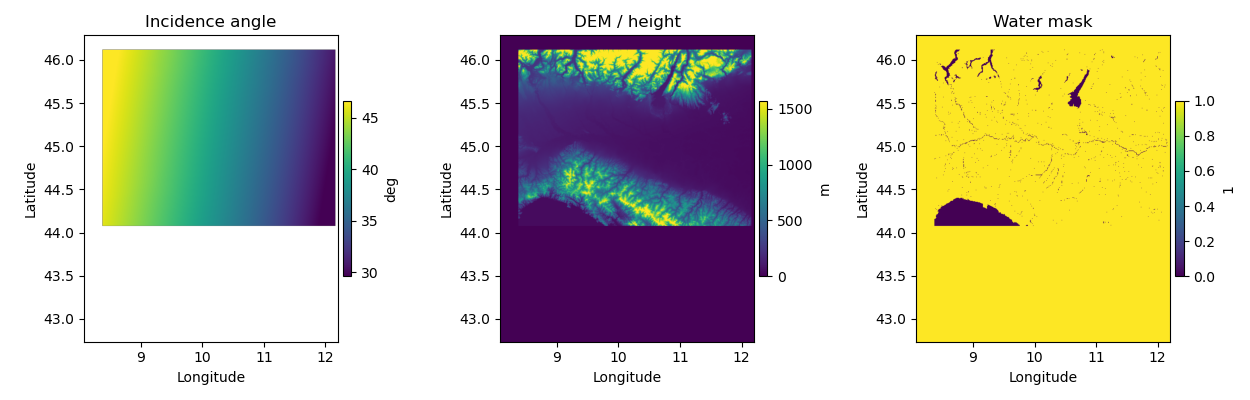

In [11]:

show_step_status('load_data')

geom_attrs = read_attrs(FILES['geometry'])
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
plot_map(axes[0], read_2d(FILES['geometry'], 'incidenceAngle', step=8), geom_attrs, 'Incidence angle', 'deg', lonlat=True, step=8)
plot_map(axes[1], read_2d(FILES['geometry'], 'height', step=8), geom_attrs, 'DEM / height', 'm', lonlat=True, step=8)
plot_map(axes[2], read_2d(FILES['geometry'], 'waterMask', step=8).astype(float), geom_attrs, 'Water mask', '1', lonlat=True, step=8)
plt.tight_layout()

print('ifgramStack summary')
display(attrs_summary(FILES['ifgramStack']))
print('geometry summary')
display(attrs_summary(FILES['geometry']))



## 2. `modify_network`

This stage evaluates interferogram connectivity and coherence.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep modify_network
```

**Main outputs**

- `avgSpatialCoh.h5`
- `waterMask.h5`
- `network.pdf`
- `coherenceMatrix.pdf`
- `coherenceHistory.pdf`
- `coherenceSpatialAvg.txt`
- `pbaseHistory.pdf`

The notebook shows both parsed text diagnostics and the native MintPy PDF network products.


,file,exists,path
0,avgSpatialCoh.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/avgSpa...
1,waterMask.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/waterM...
2,network.pdf,False,/mnt/data/aoi_3_bologna/mintpy_filtered/networ...
3,coherenceSpatialAvg.txt,True,/mnt/data/aoi_3_bologna/mintpy_filtered/cohere...


,date12,mean,btemp_days,bperp_m,index
0,20170104_20170110,0.8995,6.0,56.8,0
1,20170110_20170203,0.6807,24.0,-71.5,1
2,20170128_20170215,0.8001,18.0,-77.6,2
3,20170203_20170221,0.7573,18.0,10.7,3
4,20170209_20170215,0.9398,6.0,-79.1,4


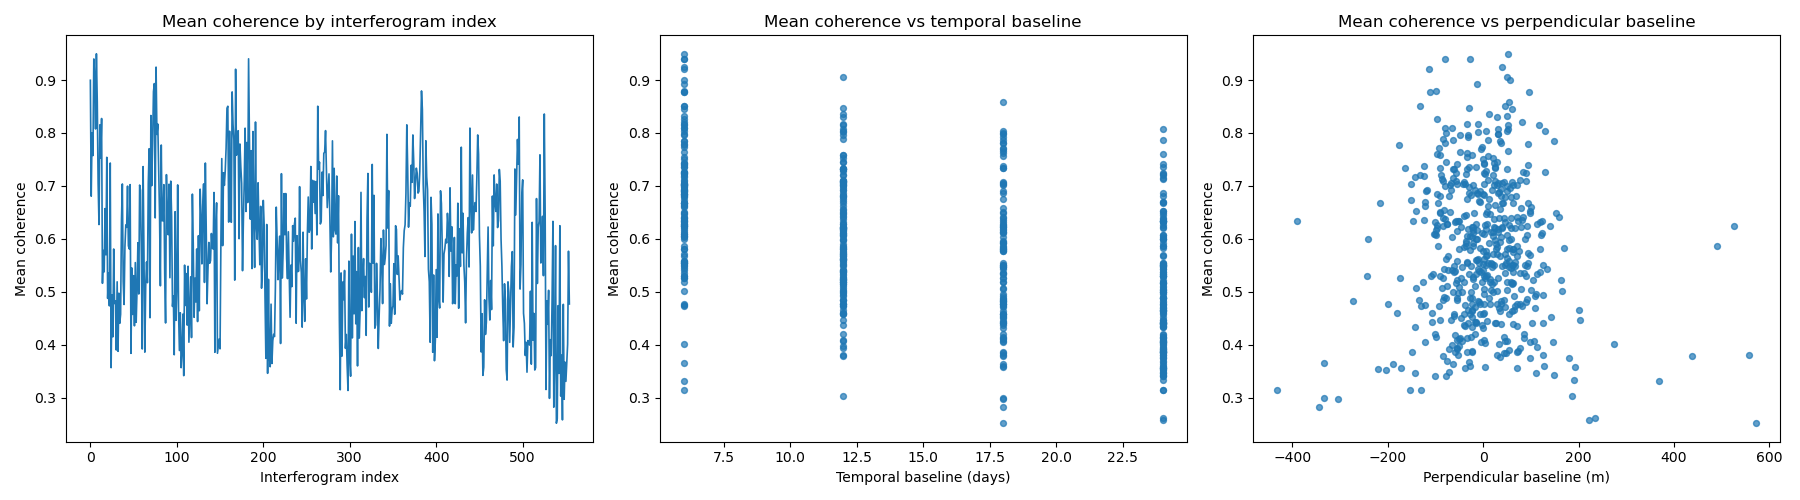

In [12]:

show_step_status('modify_network')

coh_df = parse_coherence_table(FILES['coherence_txt'])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(coh_df['index'], coh_df['mean'], lw=1.2)
axes[0].set_title('Mean coherence by interferogram index')
axes[0].set_xlabel('Interferogram index')
axes[0].set_ylabel('Mean coherence')

axes[1].scatter(coh_df['btemp_days'], coh_df['mean'], s=18, alpha=0.7)
axes[1].set_title('Mean coherence vs temporal baseline')
axes[1].set_xlabel('Temporal baseline (days)')
axes[1].set_ylabel('Mean coherence')

axes[2].scatter(coh_df['bperp_m'], coh_df['mean'], s=18, alpha=0.7)
axes[2].set_title('Mean coherence vs perpendicular baseline')
axes[2].set_xlabel('Perpendicular baseline (m)')
axes[2].set_ylabel('Mean coherence')
plt.tight_layout()

coh_df.head()


In [13]:

display(Markdown('### Network PDF'))
show_pdf(FILES['network_pdf'])

display(Markdown('### Coherence matrix PDF'))
show_pdf(FILES['coherence_matrix_pdf'])

display(Markdown('### Coherence history PDF'))
show_pdf(FILES['coherence_history_pdf'])

display(Markdown('### Perpendicular baseline history PDF'))
show_pdf(FILES['pbase_history_pdf'])


### Network PDF

Missing PDF: /mnt/data/aoi_3_bologna/mintpy_filtered/network.pdf


### Coherence matrix PDF

Missing PDF: /mnt/data/aoi_3_bologna/mintpy_filtered/coherenceMatrix.pdf


### Coherence history PDF

Missing PDF: /mnt/data/aoi_3_bologna/mintpy_filtered/coherenceHistory.pdf


### Perpendicular baseline history PDF

Missing PDF: /mnt/data/aoi_3_bologna/mintpy_filtered/pbaseHistory.pdf



## 3. `reference_point`

MintPy selected the spatial reference pixel automatically after the manual Bologna reference point proved invalid for this mask.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep reference_point
```

**Main outputs**

- updated `inputs/ifgramStack.h5` metadata
- `maskConnComp.h5`

The plot below shows the average spatial coherence with the selected reference pixel overlaid.


,file,exists,path
0,avgSpatialCoh.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/avgSpa...
1,ifgramStack.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/inputs...


Reference pixel y/x = (2405, 2740)
Reference lon/lat = (10.85951, 44.54239)


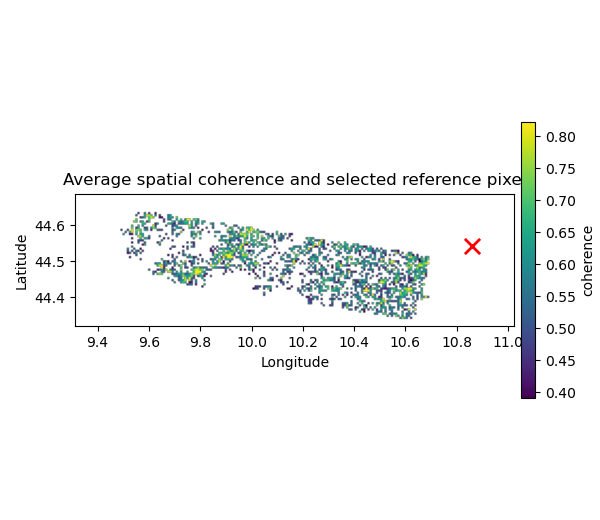

In [14]:

show_step_status('reference_point')

coh = read_2d(FILES['avgSpatialCoh'], step=8)
coh_attrs = read_attrs(FILES['avgSpatialCoh'])
ifg_attrs = read_attrs(FILES['ifgramStack'])
ref_y = int(ifg_attrs['REF_Y'])
ref_x = int(ifg_attrs['REF_X'])
step = 8
mask = make_display_mask(step=step, dilate_iter=1)

lon, lat = lonlat_from_yx(coh_attrs, ref_y, ref_x)
fig, ax = plt.subplots(figsize=(6.0, 5.2))
plot_map(ax, coh, coh_attrs, 'Average spatial coherence and selected reference pixel', 'coherence', mask=mask, lonlat=True, step=step, include_points=[(lon, lat)], pad_frac=0.12)
ax.scatter([lon], [lat], s=120, marker='x', color='red', linewidths=2)
plt.tight_layout()

print(f'Reference pixel y/x = ({ref_y}, {ref_x})')
print(f'Reference lon/lat = ({lon:.5f}, {lat:.5f})')



## 4. `quick_overview`

This is the fast sanity-check stage before full inversion.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep quick_overview
```

**Main outputs**

- `avgPhaseVelocity.h5`
- `numTriNonzeroIntAmbiguity.h5`
- `numTriNonzeroIntAmbiguity.png`

The ambiguity map is especially useful for spotting likely unwrapping trouble.


,file,exists,path
0,avgPhaseVelocity.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/avgPha...
1,numTriNonzeroIntAmbiguity.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/numTri...


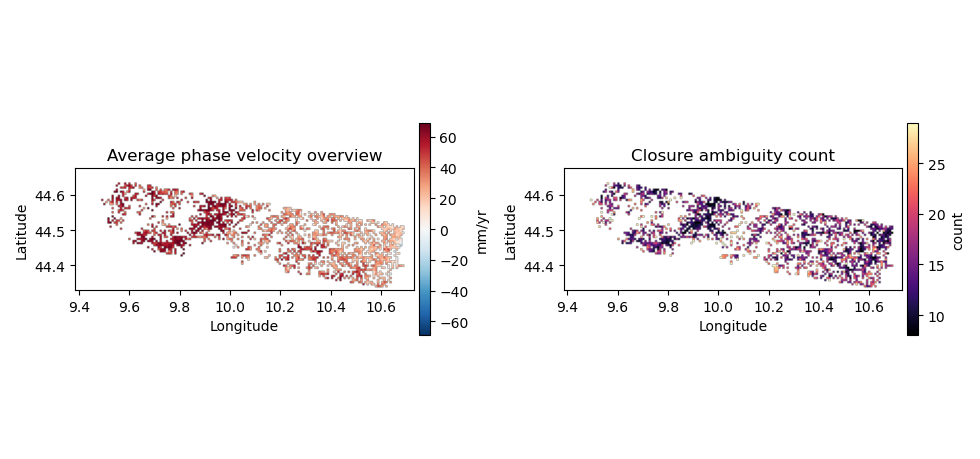

In [15]:

show_step_status('quick_overview')
mask = make_display_mask(step=8, dilate_iter=1)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.6))
plot_map(axes[0], read_2d(FILES['avgPhaseVelocity'], step=8) * 1000.0, read_attrs(FILES['avgPhaseVelocity']), 'Average phase velocity overview', 'mm/yr', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=8)
plot_map(axes[1], read_2d(FILES['ambiguity'], step=8), read_attrs(FILES['ambiguity']), 'Closure ambiguity count', 'count', cmap='magma', mask=mask, lonlat=True, step=8)
plt.tight_layout()



## 5. `invert_network`

The inversion stage produces the LOS time series and key quality layers.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep invert_network
```

**Main outputs**

- `timeseries.h5`
- `temporalCoherence.h5`
- `numInvIfgram.h5`
- `maskTempCoh.h5`

Below are the temporal coherence and the number of interferograms contributing to each pixel.


,file,exists,path
0,timeseries.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...
1,temporalCoherence.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/tempor...
2,numInvIfgram.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/numInv...
3,maskTempCoh.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/maskTe...


Raw time-series summary


FILE_TYPE           timeseries
REF_DATE              20170104
REF_Y                     2405
REF_X                     2740
LENGTH                    4881
WIDTH                     3985
X_FIRST               428520.0
Y_FIRST              5126200.0
X_STEP                    80.0
Y_STEP                   -80.0
CENTER_LINE_UTC    19626.35825
UNIT                         m
UTM_ZONE                   32N
dtype: object

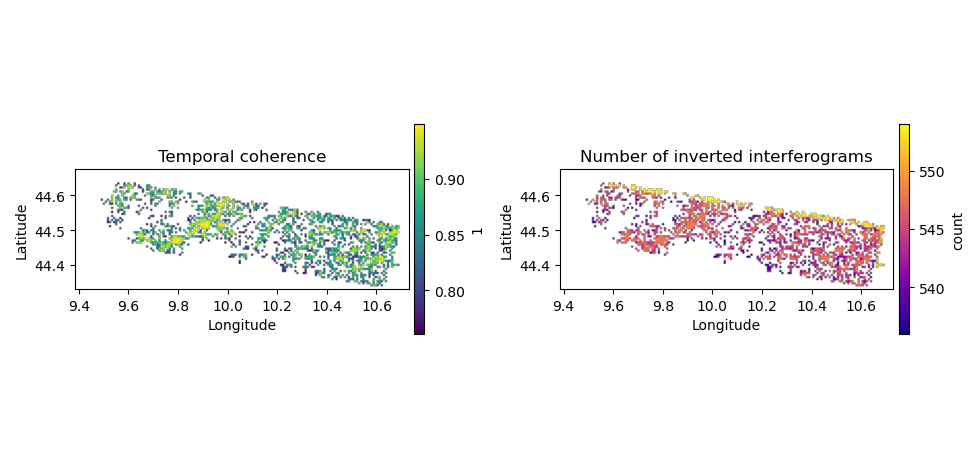

In [16]:

show_step_status('invert_network')
coh_arr = read_2d(FILES['temporalCoherence'], 'temporalCoherence', step=8)
mask = make_display_mask(step=8, dilate_iter=1) & (coh_arr > 0)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.6))
plot_map(axes[0], coh_arr, read_attrs(FILES['temporalCoherence']), 'Temporal coherence', '1', mask=mask, lonlat=True, step=8)
plot_map(axes[1], read_2d(FILES['numInvIfgram'], 'mask', step=8), read_attrs(FILES['numInvIfgram']), 'Number of inverted interferograms', 'count', cmap='plasma', mask=mask, lonlat=True, step=8)
plt.tight_layout()

print('Raw time-series summary')
display(attrs_summary(FILES['timeseries_raw']))



## 6-9. Correction Maps Through The Workflow

This section reviews the main correction stages that were kept in the AOI 3 run.

### `correct_SET`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep correct_SET
```

**Main outputs**

- `inputs/SET.h5`
- `timeseries_SET.h5`

### `correct_troposphere`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep correct_troposphere
```

**Main outputs**

- `inputs/ERA5.h5`
- `timeseries_SET_ERA5.h5`

### `deramp`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep deramp
```

**Main outputs**

- `timeseries_SET_ERA5_ramp.h5`

### `correct_topography`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep correct_topography
```

**Main outputs**

- `timeseries_SET_ERA5_ramp_demErr.h5`
- `demErr.h5`

The plots below compare the correction effect on one representative acquisition from the stack.


Representative acquisition date: 20200530


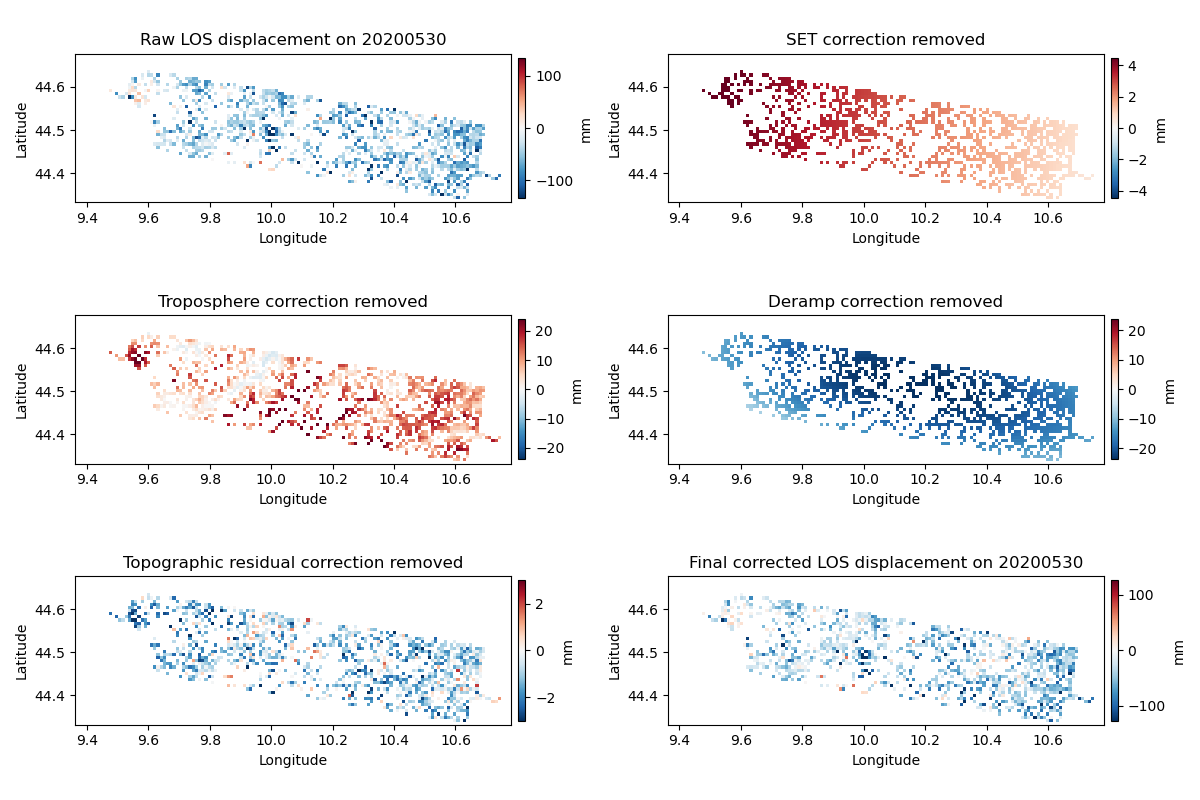

In [18]:

raw_dates, raw_dt = read_dates(FILES['timeseries_raw'])
mid_idx = len(raw_dates) // 2
sample_date = raw_dates[mid_idx]
print('Representative acquisition date:', sample_date)

attrs_ts = read_attrs(FILES['timeseries_raw'])
step = 10
mask = make_display_mask(step=step, dilate_iter=1)

raw_map = read_timeseries_slice(FILES['timeseries_raw'], mid_idx, step=step) * 1000.0
set_delta = correction_delta(FILES['timeseries_raw'], FILES['timeseries_set'], mid_idx, step=step) * 1000.0
era5_delta = correction_delta(FILES['timeseries_set'], FILES['timeseries_era5'], mid_idx, step=step) * 1000.0
ramp_delta = correction_delta(FILES['timeseries_era5'], FILES['timeseries_ramp'], mid_idx, step=step) * 1000.0
topo_delta = correction_delta(FILES['timeseries_ramp'], FILES['timeseries_final'], mid_idx, step=step) * 1000.0
final_map = read_timeseries_slice(FILES['timeseries_final'], mid_idx, step=step) * 1000.0

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
plot_map(axes[0, 0], raw_map, attrs_ts, f'Raw LOS displacement on {sample_date}', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plot_map(axes[0, 1], set_delta, attrs_ts, 'SET correction removed', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plot_map(axes[1, 0], era5_delta, attrs_ts, 'Troposphere correction removed', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plot_map(axes[1, 1], ramp_delta, attrs_ts, 'Deramp correction removed', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plot_map(axes[2, 0], topo_delta, attrs_ts, 'Topographic residual correction removed', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plot_map(axes[2, 1], final_map, attrs_ts, f'Final corrected LOS displacement on {sample_date}', 'mm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=step)
plt.tight_layout()



## 10. `residual_RMS` And `reference_date`

Residual RMS helps identify noisy acquisitions and set the temporal anchor used later in the workflow.

**Docker command for residual RMS**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep residual_RMS
```

**Main outputs from `residual_RMS`**

- `timeseriesResidual.h5`
- `timeseriesResidual_ramp.h5`
- `rms_timeseriesResidual_ramp.txt`
- `rms_timeseriesResidual_ramp.pdf`
- `reference_date.txt`

**Docker command for temporal anchoring**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep reference_date
```

The plot below shows the residual RMS curve together with the selected reference date.


,file,exists,path
0,timeseriesResidual_ramp.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/timese...
1,rms_timeseriesResidual_ramp.txt,True,/mnt/data/aoi_3_bologna/mintpy_filtered/rms_ti...
2,reference_date.txt,True,/mnt/data/aoi_3_bologna/mintpy_filtered/refere...


Reference date selected by MintPy: 20181201


,date,rms_m
109,2018-12-01,0.009384
107,2018-11-19,0.009502
119,2019-01-30,0.009847
106,2018-11-13,0.010009
77,2018-05-17,0.010052
105,2018-11-07,0.010075
149,2019-08-10,0.010147
196,2020-05-24,0.010180
101,2018-10-14,0.010257
114,2018-12-31,0.010267


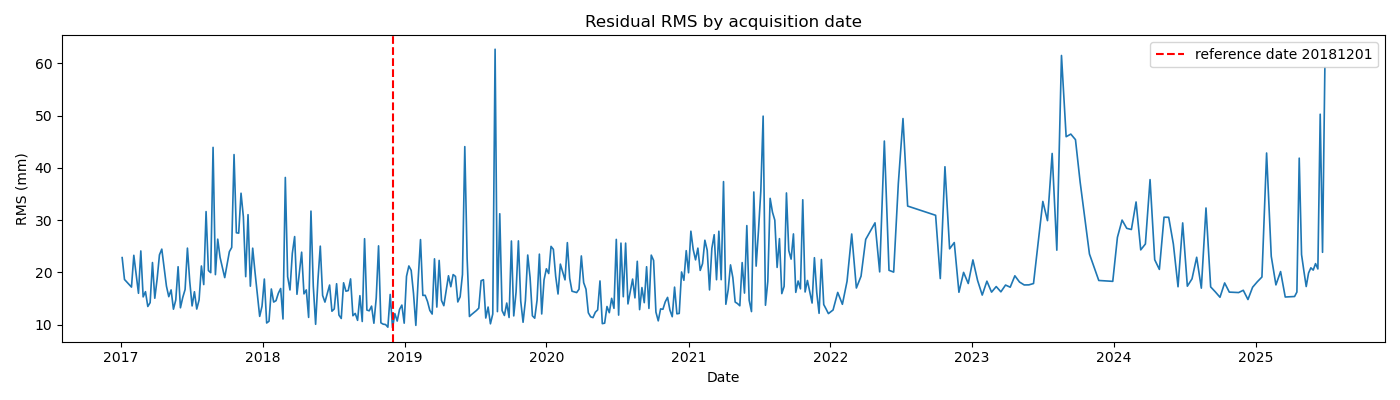

In [19]:

show_step_status('residual_RMS')

rms_df = parse_rms_table(FILES['rms_txt'])
ref_date = FILES['reference_date'].read_text().strip()
ref_dt = pd.to_datetime(ref_date, format='%Y%m%d')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rms_df['date'], rms_df['rms_m'] * 1000.0, lw=1.2)
ax.axvline(ref_dt, color='red', linestyle='--', label=f'reference date {ref_date}')
ax.set_title('Residual RMS by acquisition date')
ax.set_ylabel('RMS (mm)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()

print('Reference date selected by MintPy:', ref_date)
rms_df.sort_values('rms_m').head(10)



## 11. `velocity`

These are the main end products for the LOS deformation rate.

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep velocity
```

**Main outputs**

- `velocity.h5`
- `velocityERA5.h5`
- `velocity.png`

`velocity.h5` is the final corrected LOS velocity product used in the interactive explorer below.


,file,exists,path
0,velocity.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/veloci...
1,velocityERA5.h5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/veloci...


velocity summary


FILE_TYPE             velocity
REF_DATE              20170104
REF_Y                     2405
REF_X                     2740
LENGTH                    4881
WIDTH                     3985
X_FIRST               428520.0
Y_FIRST              5126200.0
X_STEP                    80.0
Y_STEP                   -80.0
CENTER_LINE_UTC    19626.35825
UNIT                    m/year
UTM_ZONE                   32N
dtype: object

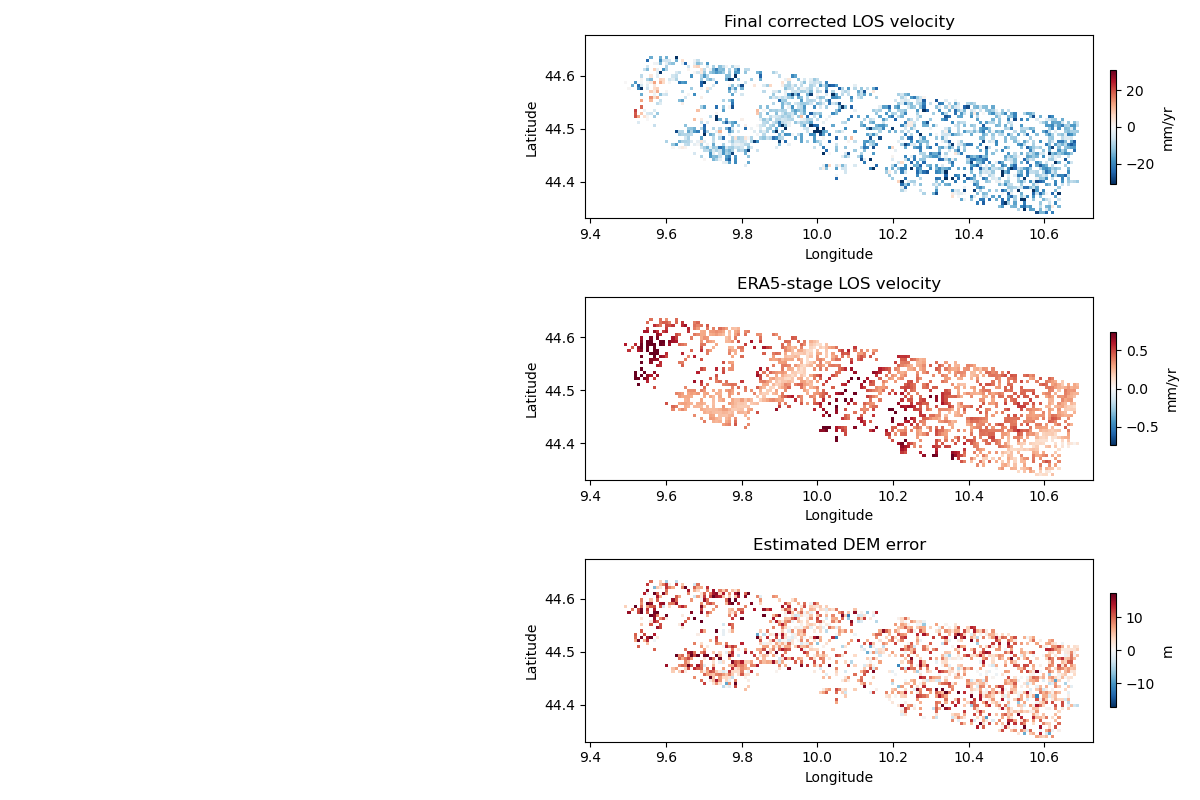

In [22]:

show_step_status('velocity')
mask = make_display_mask(step=8, dilate_iter=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
plot_map(axes[0], read_2d(FILES['velocity'], 'velocity', step=8) * 1000.0, read_attrs(FILES['velocity']), 'Final corrected LOS velocity', 'mm/yr', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=8)
plot_map(axes[1], read_2d(FILES['velocity_era5'], 'velocity', step=8) * 1000.0, read_attrs(FILES['velocity_era5']), 'ERA5-stage LOS velocity', 'mm/yr', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=8)
plot_map(axes[2], read_2d(FILES['demErr'], 'dem', step=8), read_attrs(FILES['demErr']), 'Estimated DEM error', 'm', center_zero=True, cmap='RdBu_r', mask=mask, lonlat=True, step=8)
plt.tight_layout()

print('velocity summary')
display(attrs_summary(FILES['velocity']))



## 12. Export Products

The geocoded HyP3 stack does not need a geocode stage, but the browse and archive exports remain useful.

### `geocode`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep geocode
```

**AOI 3 note**

- skipped in practice because the HyP3 stack is already geocoded

### `google_earth`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep google_earth
```

**Main output**

- `velocity.kmz`

### `hdfeos5`

**Docker command**

```bash
docker compose run --rm mintpy   smallbaselineApp.py /workspace/configs/aoi_3_bologna_hyp3_filtered.cfg   --dir /mnt/data/aoi_3_bologna/mintpy_filtered   --dostep hdfeos5
```

**Main output**

- `S1_IW123_168_0000_20170104_20250627.he5`


In [23]:

show_step_status('exports')

export_df = pd.DataFrame([
    {'product': 'Google Earth KMZ', 'path': str(FILES['kmz']), 'exists': FILES['kmz'].exists(), 'size_mb': round(FILES['kmz'].stat().st_size / 1024**2, 2) if FILES['kmz'].exists() else None},
    {'product': 'HDF-EOS5', 'path': str(FILES['he5']), 'exists': FILES['he5'].exists(), 'size_mb': round(FILES['he5'].stat().st_size / 1024**2, 2) if FILES['he5'].exists() else None},
])
display(export_df)


,file,exists,path
0,velocity.kmz,False,/mnt/data/aoi_3_bologna/mintpy_filtered/veloci...
1,S1_IW123_168_0000_20170104_20250627.he5,True,/mnt/data/aoi_3_bologna/mintpy_filtered/S1_IW1...


,product,path,exists,size_mb
0,Google Earth KMZ,/mnt/data/aoi_3_bologna/mintpy_filtered/veloci...,False,NaN
1,HDF-EOS5,/mnt/data/aoi_3_bologna/mintpy_filtered/S1_IW1...,True,936.43



## 13. Clickable Final Velocity Explorer

This section now uses a Matplotlib widget explorer instead of Plotly `FigureWidget`, so it works in the `insar` environment without `anywidget`.

**Input products used by this explorer**

- `velocity.h5`
- `temporalCoherence.h5`
- `maskTempCoh.h5`
- `inputs/geometryGeo.h5`
- `timeseries.h5`
- `timeseries_SET.h5`
- `timeseries_SET_ERA5.h5`
- `timeseries_SET_ERA5_ramp.h5`
- `timeseries_SET_ERA5_ramp_demErr.h5`

Click any point on the map to update the time-series panel.

What you will see for the selected point:

- raw LOS time series
- SET-corrected time series
- SET plus ERA5-corrected time series
- deramped time series
- final corrected time series after DEM-error correction

The map is colored by the final corrected LOS velocity from `velocity.h5` and is displayed in lon/lat.


For readability, the map uses a display-only connected support mask so the sparse side tails are hidden in the interactive view.

HTML(value='<b>Selected pixel</b><br>y/x = (2464, 1862)<br>lon/lat = (9.97480, 44.51088)<br>Final corrected ve…

Click a point on the map to update the time-series panel. The map uses a display-only support mask to suppress sparse tail artifacts. If clicks do not respond, rerun the first setup cell to re-enable the widget backend.


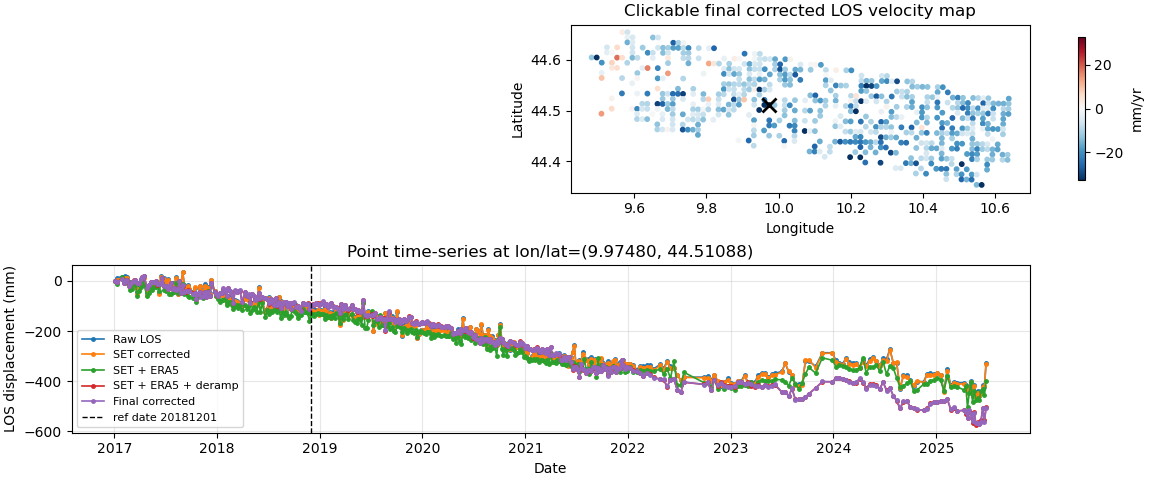

In [24]:

make_velocity_explorer(sample_step=14, coh_threshold=0.4)



## 14. Optional Follow-Up Ideas

A few useful extensions for this notebook if you want to keep exploring:

- add a date selector widget to swap the correction-map epoch interactively
- compare final LOS velocity with incidence angle to build a vertical-only approximation under the assumption of negligible horizontal motion
- add polygon or transect extraction for subsidence bowls or infrastructure corridors
- add a second explorer using temporal coherence or DEM error as the clickable map layer
